# Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Load Dataset

In [2]:
df = pd.read_csv("walkrun.csv")
df.head()


,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


# Select Sensor Columns

In [4]:
sensor_cols = [
    'acceleration_x', 'acceleration_y', 'acceleration_z',
    'gyro_x', 'gyro_y', 'gyro_z'
]


In [ ]:
# EDA – Boxplot

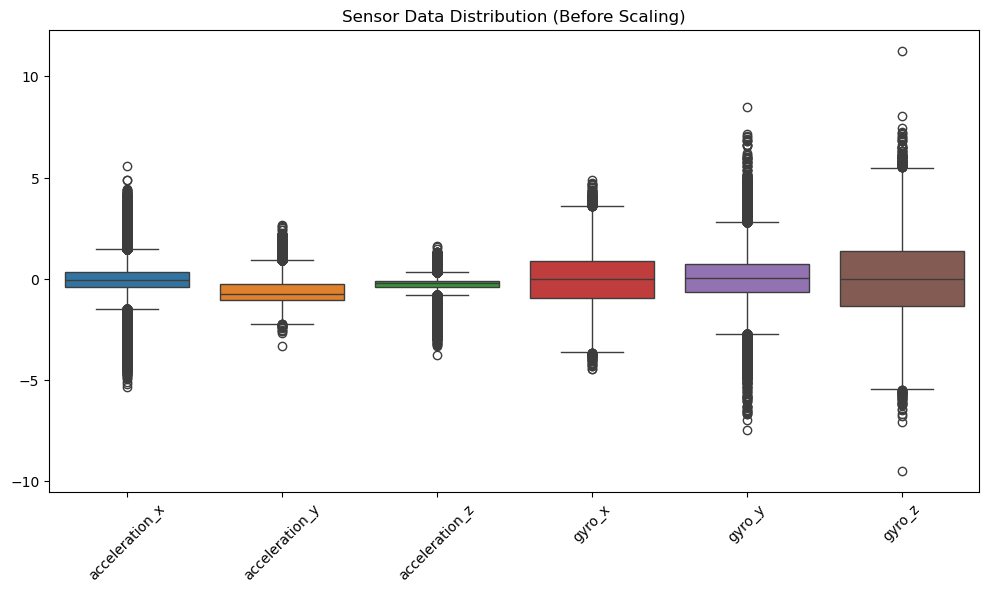

In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[sensor_cols])
plt.xticks(rotation=45)
plt.title("Sensor Data Distribution (Before Scaling)")
plt.show()


# Data Preprocessing

In [6]:
le = LabelEncoder()
df['activity'] = le.fit_transform(df['activity'])  # Walk = 0, Run = 1


In [7]:
df = df.drop(columns=['date', 'time', 'username', 'wrist'])


# Feature–Target Split

In [8]:
X = df.drop('activity', axis=1)
y = df['activity']


# Train–Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Feature Scaling

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Build Multi-Layer Neural Network (MLP)

In [11]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)


# Train the Model

In [12]:
mlp_model.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

# Model Evaluation

In [13]:
y_pred = mlp_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9920984309741506

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8845
           1       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718


Confusion Matrix:
 [[8776   69]
 [  71 8802]]


# Result Interpretation

In [14]:
# Convert predictions back to labels
predicted_labels = le.inverse_transform(y_pred)
predicted_labels[:10]


array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1])